In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tqdm.pandas()

In [24]:

EXPERIMENT_NAME = "tfidf_stack_no_leak_word13_charwb35_k35000_v1"

FORCE_TRAIN = False

BASE_DIR = "/content/drive/MyDrive/CS114/TeamModel"
DATA_DIR = os.path.join(BASE_DIR, "data")

TRAIN_PATH = os.path.join(DATA_DIR, "train_clean_tokenizedEmoji.csv")
VAL_PATH = os.path.join(DATA_DIR, "val_clean_tokenizedEmoji.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_clean_tokenizedEmoji.csv")

ARTIFACT_ROOT = os.path.join(BASE_DIR, "experiments", EXPERIMENT_NAME)
CHECKPOINT_DIR = os.path.join(ARTIFACT_ROOT, "checkpoints")
REPORT_DIR = os.path.join(ARTIFACT_ROOT, "reports")
ERROR_DIR = os.path.join(ARTIFACT_ROOT, "errors")
FIGURE_DIR = os.path.join(ARTIFACT_ROOT, "figures")

for d in [ARTIFACT_ROOT, CHECKPOINT_DIR, REPORT_DIR, ERROR_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

N_SPLITS = 3
FEATURE_K = 35000
DROP_CROSS_SPLIT_DUPLICATES = True

WORD_MAX_FEATURES = 30000
CHAR_MAX_FEATURES = 30000
WORD_MIN_DF = 3
CHAR_MIN_DF = 3

OOF_TRAIN_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_train.npy")
OOF_VAL_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_val.npy")
OOF_TEST_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_test.npy")
META_MODEL_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__meta_logistic_model.joblib")
WEIGHTS_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__class_decision_weights.json")
CONFIG_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__config.json")

config = {
    "EXPERIMENT_NAME": EXPERIMENT_NAME,
    "N_SPLITS": N_SPLITS,
    "FEATURE_K": FEATURE_K,
    "DROP_CROSS_SPLIT_DUPLICATES": DROP_CROSS_SPLIT_DUPLICATES,
    "WORD_MAX_FEATURES": WORD_MAX_FEATURES,
    "CHAR_MAX_FEATURES": CHAR_MAX_FEATURES,
    "WORD_MIN_DF": WORD_MIN_DF,
    "CHAR_MIN_DF": CHAR_MIN_DF,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Experiment:", EXPERIMENT_NAME)
print("Artifact root:", ARTIFACT_ROOT)

Experiment: tfidf_stack_no_leak_word13_charwb35_k35000_v1
Artifact root: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_no_leak_word13_charwb35_k35000_v1


In [25]:
def normalize_text_key(s):
    return str(s).strip().lower()

print("Đang tải các tập dữ liệu từ Google Drive...")
train_raw = pd.read_csv(TRAIN_PATH).dropna(subset=["text", "status"]).copy()
val_raw = pd.read_csv(VAL_PATH).dropna(subset=["text", "status"]).copy()
test_raw = pd.read_csv(TEST_PATH).dropna(subset=["text", "status"]).copy()

for df in [train_raw, val_raw, test_raw]:
    df["text_key"] = df["text"].apply(normalize_text_key)
    df["status"] = df["status"].astype(str).str.strip().str.lower()

print("Kích thước ban đầu:")
print("Train:", train_raw.shape, "Val:", val_raw.shape, "Test:", test_raw.shape)

before = len(train_raw)
train_raw = train_raw.drop_duplicates(subset=["text_key"]).reset_index(drop=True)
print(f"Đã xóa duplicate trong train: {before - len(train_raw)} mẫu")

train_keys = set(train_raw["text_key"])
val_keys = set(val_raw["text_key"])
test_keys = set(test_raw["text_key"])

overlap_stats = {
    "train_val_overlap": len(train_keys & val_keys),
    "train_test_overlap": len(train_keys & test_keys),
    "val_test_overlap": len(val_keys & test_keys),
}
print("Overlap giữa các split:", overlap_stats)

if DROP_CROSS_SPLIT_DUPLICATES:
    before_val, before_test = len(val_raw), len(test_raw)
    val_raw = val_raw[~val_raw["text_key"].isin(train_keys)].drop_duplicates(subset=["text_key"]).reset_index(drop=True)
    val_keys_after = set(val_raw["text_key"])
    test_raw = test_raw[~test_raw["text_key"].isin(train_keys | val_keys_after)].drop_duplicates(subset=["text_key"]).reset_index(drop=True)
    print(f"Đã xóa khỏi val: {before_val - len(val_raw)} mẫu duplicate/overlap")
    print(f"Đã xóa khỏi test: {before_test - len(test_raw)} mẫu duplicate/overlap")

print("Kích thước sau xử lý duplicate/overlap:")
print("Train:", train_raw.shape, "Val:", val_raw.shape, "Test:", test_raw.shape)

Đang tải các tập dữ liệu từ Google Drive...
Kích thước ban đầu:
Train: (34601, 3) Val: (4943, 3) Test: (9887, 3)
Đã xóa duplicate trong train: 16 mẫu
Overlap giữa các split: {'train_val_overlap': 4, 'train_test_overlap': 11, 'val_test_overlap': 0}
Đã xóa khỏi val: 4 mẫu duplicate/overlap
Đã xóa khỏi test: 12 mẫu duplicate/overlap
Kích thước sau xử lý duplicate/overlap:
Train: (34585, 3) Val: (4939, 3) Test: (9875, 3)


In [26]:
def extract_advanced_features(dataframe):
    df_out = dataframe.copy()
    raw_text = df_out["text"].astype(str)

    df_out["cleaned_text"] = raw_text.str.lower().str.strip()
    # Rút gọn ký tự lặp quá dài nhưng vẫn giữ tín hiệu cảm xúc như "sooo", "nooo".
    df_out["cleaned_text"] = df_out["cleaned_text"].apply(lambda x: re.sub(r"(.)\1{4,}", r"\1\1", x))

    df_out["char_len"] = raw_text.str.len()
    df_out["word_count"] = raw_text.apply(lambda x: len(x.split()))
    df_out["avg_word_len"] = df_out["char_len"] / (df_out["word_count"] + 1e-5)
    df_out["uppercase_ratio"] = raw_text.apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1e-5))

    df_out["i_pronoun_ratio"] = df_out["cleaned_text"].apply(
        lambda x: len(re.findall(r"\b(i|me|my|myself|mine)\b", x)) / (len(x.split()) + 1e-5)
    )
    df_out["negation_ratio"] = df_out["cleaned_text"].apply(
        lambda x: len(re.findall(r"\b(no|not|never|nothing|none|cannot|dont|don't|cant|can't)\b", x)) / (len(x.split()) + 1e-5)
    )
    df_out["ellipsis_count"] = raw_text.apply(lambda x: len(re.findall(r"\.\.\.", x)))
    df_out["exclamation_count"] = raw_text.apply(lambda x: x.count("!"))
    df_out["question_count"] = raw_text.apply(lambda x: x.count("?"))
    df_out["suicide_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: len(re.findall(r"\b(suicide|suicidal|kill myself|kms|kys|end my life|want to die|wanna die|die|overdose|hang myself)\b", x))
    )
    return df_out

print("Đang trích xuất đặc trưng thống kê...")
train_enriched = extract_advanced_features(train_raw)
val_enriched = extract_advanced_features(val_raw)
test_enriched = extract_advanced_features(test_raw)

feature_cols = [
    "cleaned_text", "word_count", "char_len", "avg_word_len", "uppercase_ratio",
    "i_pronoun_ratio", "negation_ratio", "ellipsis_count", "exclamation_count",
    "question_count", "suicide_keyword_count"
]

X_train, y_train = train_enriched[feature_cols], train_enriched["status"]
X_val, y_val = val_enriched[feature_cols], val_enriched["status"]
X_test, y_test = test_enriched[feature_cols], test_enriched["status"]

class_names = np.array(sorted(y_train.unique()))
n_classes = len(class_names)
print("Classes:", class_names)
print("Train label distribution:")
print(y_train.value_counts())

Đang trích xuất đặc trưng thống kê...
Classes: ['anxiety' 'depression' 'normal' 'suicidal']
Train label distribution:
status
normal        12693
depression    10153
suicidal       7840
anxiety        3899
Name: count, dtype: int64


In [27]:
def build_preprocessor():
    text_features = FeatureUnion([
        ("word_ngram", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 3),
            min_df=WORD_MIN_DF,
            max_df=0.90,
            max_features=WORD_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        )),
        ("char_ngram", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=CHAR_MIN_DF,
            max_features=CHAR_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        ))
    ])

    numeric_features = Pipeline([("scaler", MinMaxScaler())])

    return ColumnTransformer(transformers=[
        ("text", text_features, "cleaned_text"),
        ("num", numeric_features, [
            "word_count", "char_len", "avg_word_len", "uppercase_ratio",
            "i_pronoun_ratio", "negation_ratio", "ellipsis_count", "exclamation_count",
            "question_count", "suicide_keyword_count"
        ])
    ])


def fit_transform_features_no_leakage(X_tr, y_tr, X_va, X_external_list=None):

    if X_external_list is None:
        X_external_list = []

    preprocessor = build_preprocessor()
    X_tr_pre = preprocessor.fit_transform(X_tr)
    X_va_pre = preprocessor.transform(X_va)

    k_eff = min(FEATURE_K, X_tr_pre.shape[1]) if isinstance(FEATURE_K, int) else FEATURE_K
    selector = SelectKBest(score_func=chi2, k=k_eff)
    X_tr_fe = selector.fit_transform(X_tr_pre, y_tr)
    X_va_fe = selector.transform(X_va_pre)

    X_external_fe = []
    for X_ext in X_external_list:
        X_ext_pre = preprocessor.transform(X_ext)
        X_external_fe.append(selector.transform(X_ext_pre))

    return X_tr_fe, X_va_fe, X_external_fe, {"preprocessor": preprocessor, "selector": selector}


def aligned_predict_proba(model, X, target_classes):
    proba = model.predict_proba(X)
    aligned = np.zeros((X.shape[0], len(target_classes)), dtype=np.float32)
    for src_idx, cls in enumerate(model.classes_):
        dst_idx = np.where(target_classes == cls)[0][0]
        aligned[:, dst_idx] = proba[:, src_idx]
    return aligned

# Base Models
def make_base_models():
    svm = CalibratedClassifierCV(
        estimator=LinearSVC(class_weight="balanced", C=0.8, dual=False, random_state=RANDOM_STATE),
        cv=3
    )
    cnb = ComplementNB(alpha=0.1, norm=True)
    lgb = LGBMClassifier(
        class_weight="balanced",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    return {"svm": svm, "cnb": cnb, "lgb": lgb}

base_model_names = ["svm", "cnb", "lgb"]
print("Base models:", base_model_names)

Base models: ['svm', 'cnb', 'lgb']


In [28]:
if (not FORCE_TRAIN) and os.path.exists(OOF_TRAIN_PATH) and os.path.exists(OOF_VAL_PATH) and os.path.exists(OOF_TEST_PATH):
    print("Nạp OOF predictions từ checkpoint của experiment hiện tại...")
    oof_train = np.load(OOF_TRAIN_PATH)
    oof_val = np.load(OOF_VAL_PATH)
    oof_test = np.load(OOF_TEST_PATH)
else:
    oof_train = np.zeros((len(X_train), n_classes * len(base_model_names)), dtype=np.float32)
    oof_val_folds = np.zeros((len(X_val), n_classes * len(base_model_names), N_SPLITS), dtype=np.float32)
    oof_test_folds = np.zeros((len(X_test), n_classes * len(base_model_names), N_SPLITS), dtype=np.float32)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    print("Khởi chạy K-Fold stacking không leakage feature selection...")
    for fold_idx, (train_idx, fold_val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        print(f"\nFold {fold_idx}/{N_SPLITS}")
        fold_bundle_path = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__fold_{fold_idx}_bundle.joblib")

        X_tr_fold = X_train.iloc[train_idx]
        y_tr_fold = y_train.iloc[train_idx]
        X_va_fold = X_train.iloc[fold_val_idx]

        if (not FORCE_TRAIN) and os.path.exists(fold_bundle_path):
            print("Nạp fold bundle từ checkpoint...")
            bundle = joblib.load(fold_bundle_path)
            feature_pipeline = bundle["feature_pipeline"]
            models_in_fold = bundle["models"]

            preprocessor = feature_pipeline["preprocessor"]
            selector = feature_pipeline["selector"]
            X_va_fe = selector.transform(preprocessor.transform(X_va_fold))
            X_val_fe = selector.transform(preprocessor.transform(X_val))
            X_test_fe = selector.transform(preprocessor.transform(X_test))
        else:
            print("Fit TF-IDF + Chi2 trên fold train...")
            X_tr_fe, X_va_fe, external_fe, feature_pipeline = fit_transform_features_no_leakage(
                X_tr_fold, y_tr_fold, X_va_fold, X_external_list=[X_val, X_test]
            )
            X_val_fe, X_test_fe = external_fe

            print("Train base models...")
            models_in_fold = make_base_models()
            for name, model in models_in_fold.items():
                print(f"  Fit {name}...")
                model.fit(X_tr_fe, y_tr_fold)
                print(f"  {name} classes: {model.classes_}")

            bundle = {"feature_pipeline": feature_pipeline, "models": models_in_fold, "class_names": class_names}
            joblib.dump(bundle, fold_bundle_path)

        for m_idx, name in enumerate(base_model_names):
            start = m_idx * n_classes
            end = (m_idx + 1) * n_classes
            model = models_in_fold[name]

            oof_train[fold_val_idx, start:end] = aligned_predict_proba(model, X_va_fe, class_names)
            oof_val_folds[:, start:end, fold_idx - 1] = aligned_predict_proba(model, X_val_fe, class_names)
            oof_test_folds[:, start:end, fold_idx - 1] = aligned_predict_proba(model, X_test_fe, class_names)

    oof_val = oof_val_folds.mean(axis=2)
    oof_test = oof_test_folds.mean(axis=2)

    np.save(OOF_TRAIN_PATH, oof_train)
    np.save(OOF_VAL_PATH, oof_val)
    np.save(OOF_TEST_PATH, oof_test)
    print("Đã lưu OOF predictions vào:", CHECKPOINT_DIR)

print("OOF shapes:", oof_train.shape, oof_val.shape, oof_test.shape)

Nạp OOF predictions từ checkpoint của experiment hiện tại...
OOF shapes: (34585, 12) (4939, 12) (9875, 12)


In [29]:
def evaluate_base_blocks(oof_matrix, y_true, split_name):
    print(f"\n===== Base model diagnostics - {split_name} =====")
    for m_idx, name in enumerate(base_model_names):
        start = m_idx * n_classes
        end = (m_idx + 1) * n_classes
        preds = class_names[np.argmax(oof_matrix[:, start:end], axis=1)]
        print(f"{name}: Macro F1 = {f1_score(y_true, preds, average='macro'):.4f}")

evaluate_base_blocks(oof_train, y_train, "OOF Train")
evaluate_base_blocks(oof_val, y_val, "Validation")
evaluate_base_blocks(oof_test, y_test, "Test")


===== Base model diagnostics - OOF Train =====
svm: Macro F1 = 0.7847
cnb: Macro F1 = 0.7103
lgb: Macro F1 = 0.8006

===== Base model diagnostics - Validation =====
svm: Macro F1 = 0.7921
cnb: Macro F1 = 0.7097
lgb: Macro F1 = 0.8125

===== Base model diagnostics - Test =====
svm: Macro F1 = 0.7885
cnb: Macro F1 = 0.7157
lgb: Macro F1 = 0.8100


In [30]:
# Meta model

if (not FORCE_TRAIN) and os.path.exists(META_MODEL_PATH):
    print("Nạp meta model từ checkpoint của experiment hiện tại...")
    meta_model = joblib.load(META_MODEL_PATH)
else:
    print("Huấn luyện Meta Classifier - Logistic Regression...")
    meta_model = LogisticRegression(
        class_weight="balanced",
        C=1.0,
        max_iter=3000,
        random_state=RANDOM_STATE
    )
    meta_model.fit(oof_train, y_train)
    joblib.dump(meta_model, META_MODEL_PATH)

proba_train = meta_model.predict_proba(oof_train)
proba_val = meta_model.predict_proba(oof_val)
proba_test = meta_model.predict_proba(oof_test)

class_list = meta_model.classes_
print("Meta classes:", class_list)

Nạp meta model từ checkpoint của experiment hiện tại...
Meta classes: ['anxiety' 'depression' 'normal' 'suicidal']


In [31]:
def predict_with_weights(probabilities, weights, classes):
    return np.array(classes)[np.argmax(probabilities * weights, axis=1)]

# chỉ tune mạnh 2 lớp khó: depression và suicidal; các lớp còn lại giữ quanh 1.
base_weights = np.ones(len(class_list), dtype=np.float32)
idx = {cls: i for i, cls in enumerate(class_list)}

search_values = np.round(np.arange(0.70, 1.71, 0.05), 2)
best_score = -1
best_weights = base_weights.copy()
records = []

for dep_w in search_values:
    for sui_w in search_values:
        weights = base_weights.copy()
        if "depression" in idx:
            weights[idx["depression"]] = dep_w
        if "suicidal" in idx:
            weights[idx["suicidal"]] = sui_w

        preds_val = predict_with_weights(proba_val, weights, class_list)
        score = f1_score(y_val, preds_val, average="macro")
        records.append({"depression_weight": dep_w, "suicidal_weight": sui_w, "val_macro_f1": score})

        if score > best_score:
            best_score = score
            best_weights = weights.copy()

weight_dict = {cls: float(best_weights[i]) for i, cls in enumerate(class_list)}
print("Best validation Macro F1:", best_score)
print("Best class decision weights:", weight_dict)

with open(WEIGHTS_PATH, "w", encoding="utf-8") as f:
    json.dump({"best_val_macro_f1": float(best_score), "weights": weight_dict}, f, ensure_ascii=False, indent=2)

pd.DataFrame(records).sort_values("val_macro_f1", ascending=False).to_csv(
    os.path.join(REPORT_DIR, f"{EXPERIMENT_NAME}__threshold_grid_search.csv"), index=False
)

Best validation Macro F1: 0.8208123301843582
Best class decision weights: {'anxiety': 1.0, 'depression': 1.399999976158142, 'normal': 1.0, 'suicidal': 1.149999976158142}


In [32]:
preds_train_final = predict_with_weights(proba_train, best_weights, class_list)
preds_val_final = predict_with_weights(proba_val, best_weights, class_list)
preds_test_final = predict_with_weights(proba_test, best_weights, class_list)

f1_train = f1_score(y_train, preds_train_final, average="macro")
f1_val = f1_score(y_val, preds_val_final, average="macro")
f1_test = f1_score(y_test, preds_test_final, average="macro")

print("\n==================================================")
print(f"Macro F1 - OOF Train Set : {f1_train:.4f}")
print(f"Macro F1 - Val Set       : {f1_val:.4f}")
print(f"Macro F1 - Test Set      : {f1_test:.4f}")
print(f"Gap OOF Train - Val      : {f1_train - f1_val:.4f}")
print("==================================================")

report_path = os.path.join(REPORT_DIR, f"{EXPERIMENT_NAME}__classification_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    header = f"BAO CAO PHAN LOP - {EXPERIMENT_NAME}\n"
    header += "=" * 80 + "\n\n"
    header += f"Best weights: {weight_dict}\n"
    header += f"Macro F1 OOF Train: {f1_train:.4f}\n"
    header += f"Macro F1 Val:       {f1_val:.4f}\n"
    header += f"Macro F1 Test:      {f1_test:.4f}\n\n"

    print(header)
    f.write(header)

    splits = [
        ("OOF TRAIN SET", y_train, preds_train_final),
        ("VALIDATION SET", y_val, preds_val_final),
        ("TEST SET", y_test, preds_test_final),
    ]

    for name, y_true, y_pred in splits:
        section = f"--- {name} ---\n"
        section += classification_report(y_true, y_pred, digits=4)
        section += "\n" + "=" * 80 + "\n\n"
        print(section)
        f.write(section)

print("Đã lưu report tại:", report_path)


Macro F1 - OOF Train Set : 0.8052
Macro F1 - Val Set       : 0.8208
Macro F1 - Test Set      : 0.8104
Gap OOF Train - Val      : -0.0156
BAO CAO PHAN LOP - tfidf_stack_no_leak_word13_charwb35_k35000_v1

Best weights: {'anxiety': 1.0, 'depression': 1.399999976158142, 'normal': 1.0, 'suicidal': 1.149999976158142}
Macro F1 OOF Train: 0.8052
Macro F1 Val:       0.8208
Macro F1 Test:      0.8104


--- OOF TRAIN SET ---
              precision    recall  f1-score   support

     anxiety     0.8108    0.8597    0.8346      3899
  depression     0.7454    0.7300    0.7377     10153
      normal     0.9334    0.9265    0.9299     12693
    suicidal     0.7155    0.7218    0.7186      7840

    accuracy                         0.8149     34585
   macro avg     0.8013    0.8095    0.8052     34585
weighted avg     0.8150    0.8149    0.8148     34585



--- VALIDATION SET ---
              precision    recall  f1-score   support

     anxiety     0.8408    0.8815    0.8606       557
  depression

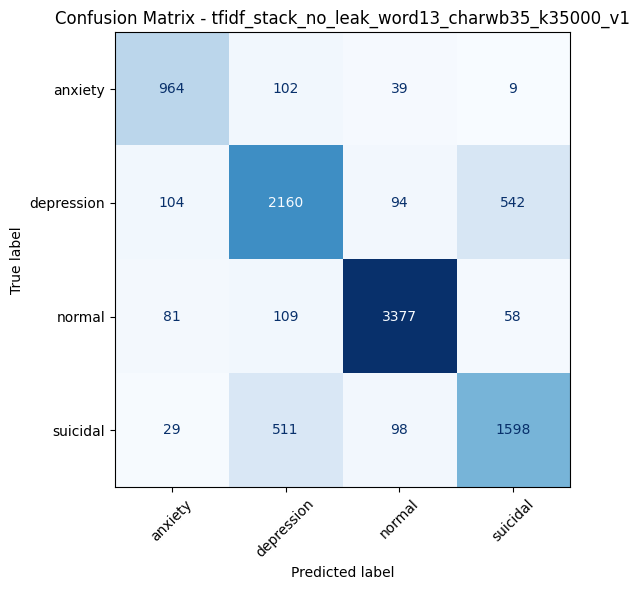

Đã lưu confusion matrix tại: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_no_leak_word13_charwb35_k35000_v1/figures/tfidf_stack_no_leak_word13_charwb35_k35000_v1__confusion_matrix_test.png


In [33]:
# Confusion matrix - Test set
cm = confusion_matrix(y_test, preds_test_final, labels=class_list)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_list)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title(f"Confusion Matrix - {EXPERIMENT_NAME}")
plt.tight_layout()
cm_path = os.path.join(FIGURE_DIR, f"{EXPERIMENT_NAME}__confusion_matrix_test.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()
print("Đã lưu confusion matrix tại:", cm_path)

In [34]:
# Error analysis tập trung depression <-> suicidal và các lỗi liên quan 2 lớp khó.
error_df = pd.DataFrame({
    "text": test_raw["text"].values,
    "true": y_test.values,
    "pred": preds_test_final,
})
error_df["is_error"] = error_df["true"] != error_df["pred"]

dep_sui_errors = error_df[
    ((error_df["true"] == "depression") & (error_df["pred"] == "suicidal")) |
    ((error_df["true"] == "suicidal") & (error_df["pred"] == "depression"))
].copy()

hard_class_errors = error_df[
    error_df["is_error"] & (error_df["true"].isin(["depression", "suicidal"]) | error_df["pred"].isin(["depression", "suicidal"]))
].copy()

all_errors_path = os.path.join(ERROR_DIR, f"{EXPERIMENT_NAME}__all_test_errors.csv")
dep_sui_path = os.path.join(ERROR_DIR, f"{EXPERIMENT_NAME}__depression_suicidal_errors.csv")
hard_errors_path = os.path.join(ERROR_DIR, f"{EXPERIMENT_NAME}__hard_class_errors.csv")

error_df[error_df["is_error"]].to_csv(all_errors_path, index=False)
dep_sui_errors.to_csv(dep_sui_path, index=False)
hard_class_errors.to_csv(hard_errors_path, index=False)

print("Số lỗi test:", int(error_df["is_error"].sum()))
print("Số lỗi depression <-> suicidal:", len(dep_sui_errors))
print("Đã lưu error analysis:")
print(all_errors_path)
print(dep_sui_path)
print(hard_errors_path)

if len(dep_sui_errors) > 0:
    display(dep_sui_errors.sample(min(20, len(dep_sui_errors)), random_state=RANDOM_STATE))
else:
    print("Không có lỗi depression <-> suicidal trong test set.")

Số lỗi test: 1776
Số lỗi depression <-> suicidal: 1053
Đã lưu error analysis:
/content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_no_leak_word13_charwb35_k35000_v1/errors/tfidf_stack_no_leak_word13_charwb35_k35000_v1__all_test_errors.csv
/content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_no_leak_word13_charwb35_k35000_v1/errors/tfidf_stack_no_leak_word13_charwb35_k35000_v1__depression_suicidal_errors.csv
/content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_no_leak_word13_charwb35_k35000_v1/errors/tfidf_stack_no_leak_word13_charwb35_k35000_v1__hard_class_errors.csv


,text,true,pred,is_error
3714,just staring at my packed up apartment and fee...,suicidal,depression,True
1032,why did you let myself think anyone would care...,depression,suicidal,True
9092,fuck me. i have a lot of anger in me. i am not...,depression,suicidal,True
9863,my bf said i dont try to make it better for my...,depression,suicidal,True
642,sometimes it hits me how literally nobody know...,depression,suicidal,True
2922,attempters are relieved when they fail to kill...,depression,suicidal,True
2494,i gave myself a year to try to be happy. but i...,suicidal,depression,True
3086,why did not you tell me you googled about suic...,depression,suicidal,True
7945,this question sounds real dumb to even myself ...,depression,suicidal,True
1465,my girlfriend of 3 years recently committed su...,suicidal,depression,True


Phần này để chuẩn bị dữ liệu cho Error Analysis, nếu chỉ xem model thôi thì không cần để ý

In [35]:

import os
import numpy as np
import pandas as pd

EA_EXPORT_DIR = "/content/drive/MyDrive/CS114/TeamModel/error_analysis_exports"
os.makedirs(EA_EXPORT_DIR, exist_ok=True)

np.save(f"{EA_EXPORT_DIR}/preds_test_final.npy", np.array(preds_test_final))
np.save(f"{EA_EXPORT_DIR}/proba_test.npy", np.array(proba_test))
np.save(f"{EA_EXPORT_DIR}/oof_test.npy", np.array(oof_test))
np.save(f"{EA_EXPORT_DIR}/class_list.npy", np.array(class_list))
np.save(f"{EA_EXPORT_DIR}/y_test.npy", np.array(y_test))

print("Saved prediction files to:", EA_EXPORT_DIR)

Saved prediction files to: /content/drive/MyDrive/CS114/TeamModel/error_analysis_exports


In [36]:

import os
import numpy as np
import pandas as pd

EA_TEST_PATH = "/content/drive/MyDrive/CS114/TeamModel/data/test_clean_tokenizedEmoji_ea.csv"
EA_EXPORT_DIR = "/content/drive/MyDrive/CS114/TeamModel/error_analysis_exports"
os.makedirs(EA_EXPORT_DIR, exist_ok=True)

test_ea = pd.read_csv(EA_TEST_PATH, encoding="utf-8")

def normalize_text_key(s):
    return str(s).strip().lower()

# test_raw là test set thực tế sau khi notebook training đã filter/drop overlap
test_model = test_raw.copy().reset_index(drop=True)
test_model["test_position"] = np.arange(len(test_model))
test_model["text_key"] = test_model["text"].apply(normalize_text_key)
test_model["status"] = test_model["status"].astype(str).str.strip().str.lower()

test_ea_merge = test_ea.copy()
test_ea_merge["text_key"] = test_ea_merge["text"].apply(normalize_text_key)
test_ea_merge["status"] = test_ea_merge["status"].astype(str).str.strip().str.lower()

# Xử lý trường hợp trùng text + status bằng số thứ tự xuất hiện
test_model["occ"] = test_model.groupby(["text_key", "status"]).cumcount()
test_ea_merge["occ"] = test_ea_merge.groupby(["text_key", "status"]).cumcount()

export_df = test_model.merge(
    test_ea_merge[["row_id", "text_original", "text", "status", "text_key", "occ"]],
    on=["text_key", "status", "occ"],
    how="left",
    suffixes=("_model", "_ea")
)

print("Actual test rows:", len(test_model))
print("Merged rows:", len(export_df))
print("Missing text_original:", export_df["text_original"].isna().sum())

# Thêm nhãn thật và dự đoán
export_df["true_label"] = np.array(y_test)
export_df["pred_label"] = np.array(preds_test_final)
export_df["is_error"] = export_df["true_label"] != export_df["pred_label"]

# Thêm xác suất final
class_list_arr = np.array(class_list)

for i, cls in enumerate(class_list_arr):
    export_df[f"prob_{cls}"] = proba_test[:, i]

top1_idx = np.argmax(proba_test, axis=1)
top2_idx = np.argsort(proba_test, axis=1)[:, -2]

export_df["top1_label"] = class_list_arr[top1_idx]
export_df["top1_prob"] = np.max(proba_test, axis=1)
export_df["top2_label"] = class_list_arr[top2_idx]
export_df["top2_prob"] = proba_test[np.arange(len(proba_test)), top2_idx]
export_df["margin"] = export_df["top1_prob"] - export_df["top2_prob"]

# Thêm base model predictions nếu có oof_test
n_classes = len(class_list_arr)

svm_proba = oof_test[:, 0:n_classes]
cnb_proba = oof_test[:, n_classes:2*n_classes]
lgb_proba = oof_test[:, 2*n_classes:3*n_classes]

export_df["svm_pred"] = class_list_arr[np.argmax(svm_proba, axis=1)]
export_df["cnb_pred"] = class_list_arr[np.argmax(cnb_proba, axis=1)]
export_df["lgb_pred"] = class_list_arr[np.argmax(lgb_proba, axis=1)]

export_df["svm_conf"] = np.max(svm_proba, axis=1)
export_df["cnb_conf"] = np.max(cnb_proba, axis=1)
export_df["lgb_conf"] = np.max(lgb_proba, axis=1)

# Đổi tên cho rõ
export_df = export_df.rename(columns={
    "text_model": "processed_text",
    "text_original": "text_original"
})

# Giữ các cột quan trọng
front_cols = [
    "test_position",
    "row_id",
    "text_original",
    "processed_text",
    "status",
    "true_label",
    "pred_label",
    "is_error",
    "top1_label",
    "top1_prob",
    "top2_label",
    "top2_prob",
    "margin",
]

prob_cols = [f"prob_{cls}" for cls in class_list_arr]

base_cols = [
    "svm_pred", "cnb_pred", "lgb_pred",
    "svm_conf", "cnb_conf", "lgb_conf"
]

keep_cols = front_cols + prob_cols + base_cols
keep_cols = [c for c in keep_cols if c in export_df.columns]

export_df = export_df[keep_cols]

OUT_PATH = f"{EA_EXPORT_DIR}/test_error_analysis_base.csv"

export_df.to_csv(
    OUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", OUT_PATH)
display(export_df.head())

Actual test rows: 9875
Merged rows: 9875
Missing text_original: 0
Saved: /content/drive/MyDrive/CS114/TeamModel/error_analysis_exports/test_error_analysis_base.csv


,test_position,row_id,text_original,processed_text,status,true_label,pred_label,is_error,top1_label,top1_prob,...,prob_anxiety,prob_depression,prob_normal,prob_suicidal,svm_pred,cnb_pred,lgb_pred,svm_conf,cnb_conf,lgb_conf
0,0,0,i don’t know why i feel so irrationally. i hav...,i don't know why i feel so irrationally. i hav...,anxiety,anxiety,anxiety,False,anxiety,0.983720,...,0.983720,0.009237,0.005754,0.001289,anxiety,anxiety,anxiety,0.741441,0.250001,0.951468
1,1,1,There were a lot of moms protesting quarintine...,there were a lot of moms protesting quarintine...,normal,normal,normal,False,normal,0.926259,...,0.027818,0.018596,0.926259,0.027328,normal,normal,normal,0.784751,0.250001,0.910596
2,2,2,doesn t want him to go,doesn t want him to go,normal,normal,normal,False,normal,0.966059,...,0.015237,0.007158,0.966059,0.011546,normal,normal,normal,0.910239,0.250001,0.994331
3,3,3,"Yes, I can take a day off 'ƒ","yes, i can take a day off '",normal,normal,normal,False,normal,0.964200,...,0.016183,0.007393,0.964200,0.012224,normal,normal,normal,0.915298,0.250002,0.980031
4,4,4,people try to be funny with me and i can't thi...,people try to be funny with me and i can't thi...,anxiety,anxiety,anxiety,False,anxiety,0.743190,...,0.743190,0.182258,0.044570,0.029982,depression,depression,anxiety,0.416304,0.250000,0.513087


In [37]:
test_raw.to_csv(
    "/content/drive/MyDrive/CS114/TeamModel/error_analysis_exports/test_used_by_model.csv",
    index=False,
    encoding="utf-8-sig"
)

Đóng gói model vào một file duy nhất

In [38]:


import os
import json
import joblib
import numpy as np

PACKAGE_DIR = "/content/drive/MyDrive/CS114/TeamModel/demo_model"
os.makedirs(PACKAGE_DIR, exist_ok=True)

PACKAGE_PATH = f"{PACKAGE_DIR}/tfidf_stacking_demo_bundle.joblib"

# Load fold bundles
fold_bundles = []

for fold_idx in range(1, N_SPLITS + 1):
    fold_path = os.path.join(
        CHECKPOINT_DIR,
        f"{EXPERIMENT_NAME}__fold_{fold_idx}_bundle.joblib"
    )

    bundle = joblib.load(fold_path)
    fold_bundles.append(bundle)

# Load meta model
meta_model_path = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__meta_logistic_model.joblib"
)

meta_model_packaged = joblib.load(meta_model_path)

# Load class decision weights
weights_path = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__class_decision_weights.json"
)

with open(weights_path, "r", encoding="utf-8") as f:
    class_decision_weights_json = json.load(f)

# JSON của bạn có key "weights"
weights_dict = class_decision_weights_json["weights"]

class_list_arr = np.array(class_list)

weights_array = np.array([
    weights_dict[cls] for cls in class_list_arr
], dtype=np.float32)

# Đóng gói tất cả vào một object
demo_bundle = {
    "experiment_name": EXPERIMENT_NAME,
    "fold_bundles": fold_bundles,
    "meta_model": meta_model_packaged,
    "class_list": class_list_arr,
    "class_decision_weights": weights_array,
    "class_decision_weights_dict": weights_dict,
    "best_val_macro_f1": class_decision_weights_json.get("best_val_macro_f1", None),
    "n_splits": N_SPLITS,
    "note": "Full TF-IDF stacking model bundle for demo inference."
}

joblib.dump(demo_bundle, PACKAGE_PATH)

print("Saved full demo model bundle:")
print(PACKAGE_PATH)

print("Classes:", class_list_arr)
print("Weights array:", weights_array)
print("Weights dict:", weights_dict)

Saved full demo model bundle:
/content/drive/MyDrive/CS114/TeamModel/demo_model/tfidf_stacking_demo_bundle.joblib
Classes: ['anxiety' 'depression' 'normal' 'suicidal']
Weights array: [1.   1.4  1.   1.15]
Weights dict: {'anxiety': 1.0, 'depression': 1.399999976158142, 'normal': 1.0, 'suicidal': 1.149999976158142}
